<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>04 → Naive Bayes Classification on Wine Dataset</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Multiclass Gaussian Likelihoods, Bayes' Theorem, Conditional Independence, Variance Smoothing & Decision Landscapes)</span>
</div>


---

# Table of Contents 

1. [Task 1: Theoretical Foundations: Bayes' Theorem & Conditional Independence](#1-theoretical-foundations)
2. [Task 2: Gaussian Likelihood Formulation & Class-Conditional Densities](#2-gaussian-formulation)
3. [Task 3: Import Libraries & Ingest the 13-Feature Wine Recognition Dataset](#3-import-libraries-data)
4. [Task 4: Exploratory Data Analysis (EDA) & Chemical Fingerprinting](#4-eda-chemical-profiles)
5. [Task 5: Evaluating the Independence Assumption (Correlation Structure)](#5-correlation-independence)
6. [Task 6: Testing the Normality (Gaussian) Assumption via KDE & Q-Q Plots](#6-normality-diagnostics)
7. [Task 7: Stratified Train-Test Split & Feature Preparation](#7-stratified-split)
8. [Task 8: Training Gaussian Naive Bayes & Extracting Learned Parameters (Class Means & Variances)](#8-training-gaussian-nb)
9. [Task 9: Visualizing Learned Class-Conditional Probability Densities](#9-visualizing-densities)
10. [Task 10: Posterior Probability Distributions & Model Certainty](#10-posterior-certainty)
11. [Task 11: Hyperparameter Optimization -- Variance Smoothing (`var_smoothing`)](#11-variance-smoothing-tuning)
12. [Task 12: Multiclass Classifier Benchmarking (GaussianNB vs ComplementNB vs LogReg vs KNN)](#12-classifier-benchmarking)
13. [Task 13: 2D Decision Boundary Landscapes via PCA Space](#13-pca-decision-boundary)
14. [Task 14: Comprehensive Final Model Evaluation (Confusion Matrix & Multiclass ROC-AUC)](#14-model-evaluation)
15. [Task 15: Strengths, Failure Modes & Practical Takeaways](#15-summary-takeaways)

---


<a id="1-theoretical-foundations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Task 1: Theoretical Foundations: Bayes' Theorem & Conditional Independence</span>


### 1. Bayes' Theorem for Multiclass Classification
Given a feature observation vector $\mathbf{x} = (x_1, x_2, \dots, x_d) \in \mathbb{R}^d$ and a discrete set of classes $C_k \in \{C_1, C_2, \dots, C_K\}$, Bayes' rule defines the **posterior probability** as:

$$
P(C_k \mid \mathbf{x}) = \frac{P(C_k) \, P(\mathbf{x} \mid C_k)}{P(\mathbf{x})} = \frac{P(C_k) \, P(\mathbf{x} \mid C_k)}{\sum_{j=1}^K P(C_j) \, P(\mathbf{x} \mid C_j)}
$$

Where:
- $P(C_k)$ is the **Prior Probability** (the base rate of class $C_k$ in the population).
- $P(\mathbf{x} \mid C_k)$ is the **Likelihood** (the probability of observing features $\mathbf{x}$ given class $C_k$).
- $P(\mathbf{x})$ is the **Evidence** (a normalizing constant independent of $C_k$).
- $P(C_k \mid \mathbf{x})$ is the updated **Posterior Probability**.

### 2. The "Naive" Conditional Independence Assumption
Modeling the joint distribution $P(x_1, x_2, \dots, x_d \mid C_k)$ directly requires estimating an exponential number of parameters. Naive Bayes makes the assumption that **all features are mutually conditionally independent given the class label $C_k$**:

$$
P(\mathbf{x} \mid C_k) = P(x_1, x_2, \dots, x_d \mid C_k) = \prod_{i=1}^d P(x_i \mid C_k)
$$

### 3. Maximum A Posteriori (MAP) Decision Rule
Since the evidence $P(\mathbf{x})$ is identical across all classes, the classification decision maximizes the joint probability:

$$
\hat{y} = \operatorname{argmax}_{k \in \{1, \dots, K\}} P(C_k) \prod_{i=1}^d P(x_i \mid C_k)
$$

In practice, to avoid numerical floating-point underflow when multiplying many small probabilities, we compute in the **log-probability domain**:

$$
\hat{y} = \operatorname{argmax}_{k \in \{1, \dots, K\}} \left( \ln P(C_k) + \sum_{i=1}^d \ln P(x_i \mid C_k) \right)
$$


<a id="2-gaussian-formulation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 2: Gaussian Likelihood Formulation & Class-Conditional Densities</span>


When features are continuous real-valued variables (like chemical concentrations in wine), **Gaussian Naive Bayes** assumes that within each class $C_k$, feature $x_i$ follows a univariate Normal distribution:

$$
P(x_i \mid C_k) = \frac{1}{\sqrt{2\pi \sigma_{ik}^2}} \exp\left( -\frac{(x_i - \mu_{ik})^2}{2\sigma_{ik}^2} \right)
$$

Where:
- $\mu_{ik}$ is the sample mean of feature $i$ in class $k$:

$$
\mu_{ik} = \frac{1}{N_k} \sum_{j \in C_k} x_{j, i}
$$

- $\sigma_{ik}^2$ is the sample variance of feature $i$ in class $k$:

$$
\sigma_{ik}^2 = \frac{1}{N_k} \sum_{j \in C_k} (x_{j, i} - \mu_{ik})^2
$$

**Variance Smoothing (`var_smoothing`):**
If a feature has very small or zero variance in a class, division by $\sigma_{ik}^2$ causes numerical instability. Scikit-learn adds an additive stability factor:

$$
\sigma_{ik,\mathrm{smoothed}}^2 = \sigma_{ik}^2 + \epsilon \cdot \max(\sigma^2)
$$

where $\epsilon$ is the variance smoothing parameter (\texttt{var\_smoothing}, default $10^{-9}$).


<a id="3-import-libraries-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 3: Import Libraries & Ingest the 13-Feature Wine Recognition Dataset</span>


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_curve, 
    auc
)
from sklearn.decomposition import PCA

# Configure plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Load Wine Cultivar Dataset (derived from 3 cultivars in Italy)
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
df_wine['cultivar'] = df_wine['target'].map({0: 'Cultivar 1', 1: 'Cultivar 2', 2: 'Cultivar 3'})

print(f"Dataset Size: {df_wine.shape[0]} wine samples with {len(wine.feature_names)} continuous chemical attributes")
print(f"Class Breakdown: {dict(df_wine['cultivar'].value_counts())}")
display(df_wine.head(4).T.iloc[:9])

Dataset Size: 178 wine samples with 13 continuous chemical attributes
Class Breakdown: {'Cultivar 2': np.int64(71), 'Cultivar 1': np.int64(59), 'Cultivar 3': np.int64(48)}


,0,1,2,3
alcohol,14.23,13.2,13.16,14.37
malic_acid,1.71,1.78,2.36,1.95
ash,2.43,2.14,2.67,2.5
alcalinity_of_ash,15.6,11.2,18.6,16.8
magnesium,127.0,100.0,101.0,113.0
total_phenols,2.8,2.65,2.8,3.85
flavanoids,3.06,2.76,3.24,3.49
nonflavanoid_phenols,0.28,0.26,0.3,0.24
proanthocyanins,2.29,1.28,2.81,2.18


<a id="4-eda-chemical-profiles"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 4: Exploratory Data Analysis (EDA) & Chemical Fingerprinting</span>


In [ ]:
# PLOT 1 & 2: Cultivar Class Distribution and Key Chemical Profiles
fig = plt.figure(figsize=(16, 9))

# Subplot 1: Target Distribution
ax_bar = plt.subplot2grid((2, 3), (0, 0))
cult_palette = {'Cultivar 1': 'indigo', 'Cultivar 2': 'crimson', 'Cultivar 3': 'orange'}
sns.countplot(data=df_wine, x='cultivar', hue='cultivar', legend=False, palette=cult_palette, ax=ax_bar, alpha=0.85)
ax_bar.set_title("Figure 1: Samples per Wine Cultivar", fontweight='bold')
ax_bar.set_xlabel("Wine Class")
ax_bar.set_ylabel("Bottle Sample Count")
for p in ax_bar.patches:
    ax_bar.annotate(f"{int(p.get_height())}\n({p.get_height()/len(df_wine)*100:.1f}%)",
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Subplots 2: Key Chemical Feature Boxplots (Alcohol, Flavanoids, Color Intensity, Proline, Malic Acid)
key_chem = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'malic_acid']
positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for idx, chem in enumerate(key_chem):
    ax = plt.subplot2grid((2, 3), positions[idx])
    sns.boxplot(data=df_wine, x='cultivar', hue='cultivar', legend=False, y=chem, palette=cult_palette, ax=ax, width=0.45, boxprops=dict(alpha=0.75))
    sns.stripplot(data=df_wine, x='cultivar', y=chem, color='black', alpha=0.4, jitter=0.2, size=4, ax=ax)
    ax.set_title(f"{chem.replace('_', ' ').title()}", fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Measured Concentration")

plt.suptitle("Figure 1 & 2: Chemical Fingerprint Variance Across Cultivars", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="5-correlation-independence"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 5: Evaluating the Independence Assumption (Correlation Structure)</span>


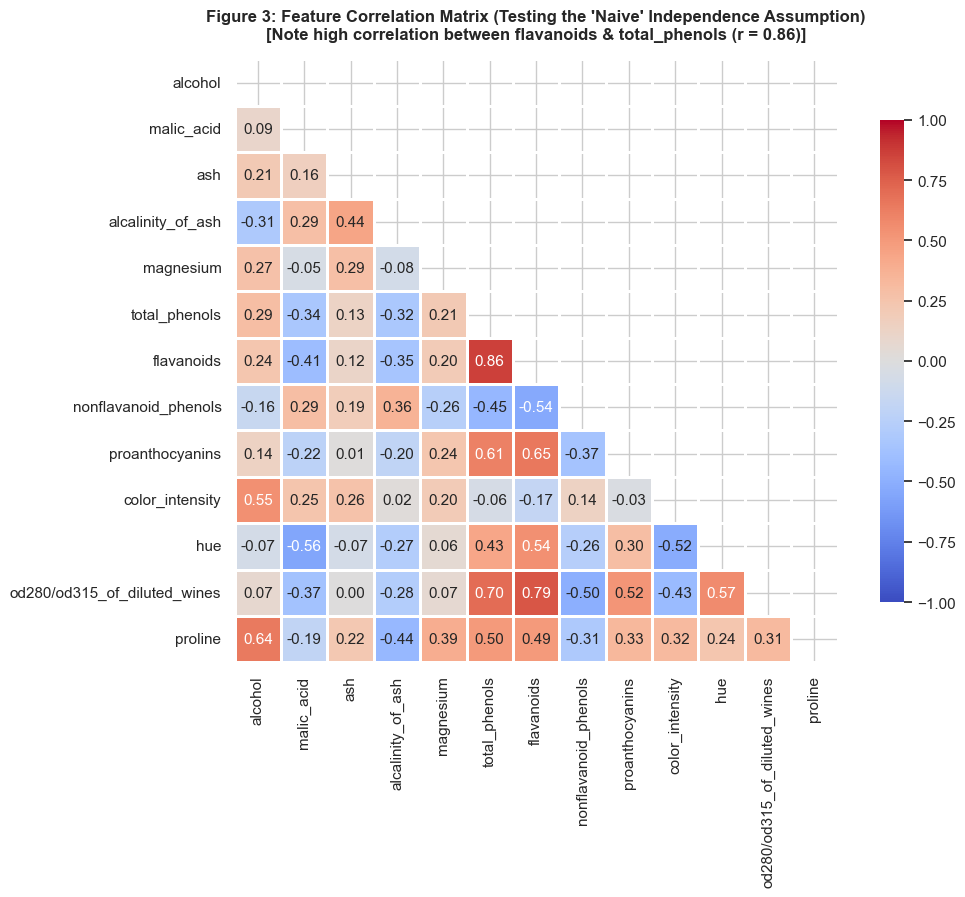

In [9]:
# PLOT 3: Pearson Correlation Heatmap Among All 13 Chemical Attributes
plt.figure(figsize=(11, 9))
corr = df_wine[wine.feature_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Figure 3: Feature Correlation Matrix (Testing the 'Naive' Independence Assumption)\n[Note high correlation between flavanoids & total_phenols (r = 0.86)]", 
          pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="6-normality-diagnostics"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 6: Testing the Normality (Gaussian) Assumption via KDE & Q-Q Plots</span>


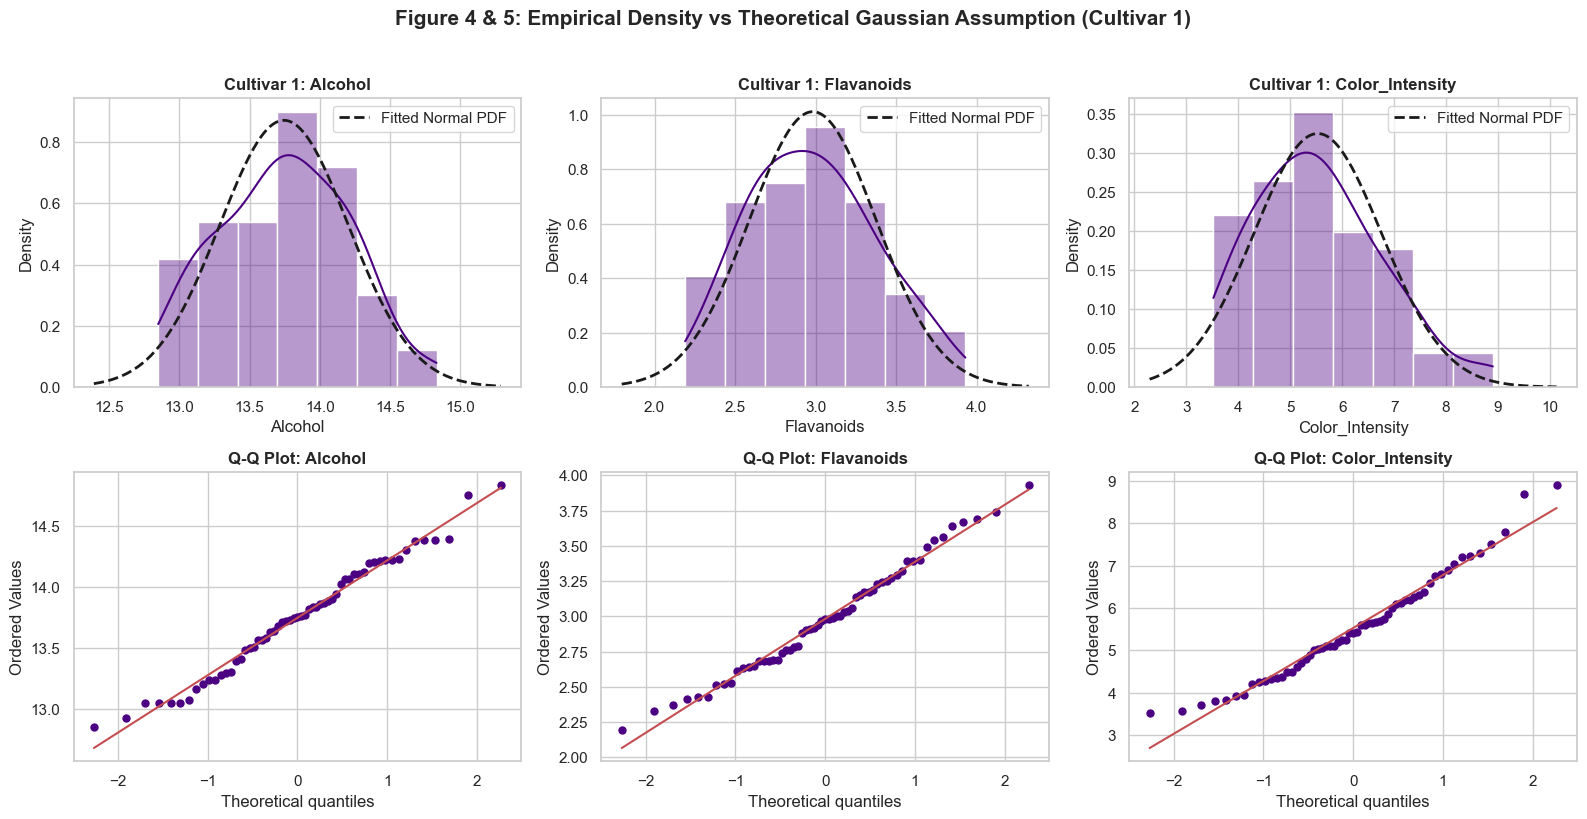

In [10]:
# PLOT 4 & 5: Normality Diagnostics (KDE Overlay & Q-Q Probability Plots)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

selected_features = ['alcohol', 'flavanoids', 'color_intensity']

# Row 1: KDE vs Theoretical Gaussian overlay for Cultivar 1
for i, feat in enumerate(selected_features):
    vals = df_wine[df_wine['target'] == 0][feat].values
    mu, sigma = np.mean(vals), np.std(vals)
    x_grid = np.linspace(vals.min() - sigma, vals.max() + sigma, 200)
    normal_pdf = stats.norm.pdf(x_grid, mu, sigma)
    
    sns.histplot(vals, kde=True, stat='density', color='indigo', alpha=0.4, ax=axes[0, i])
    axes[0, i].plot(x_grid, normal_pdf, 'k--', linewidth=2, label='Fitted Normal PDF')
    axes[0, i].set_title(f"Cultivar 1: {feat.title()}", fontweight='bold')
    axes[0, i].set_xlabel(feat.title())
    axes[0, i].legend()

# Row 2: Quantile-Quantile (Q-Q) Plots against Theoretical Normal Quantiles
for i, feat in enumerate(selected_features):
    vals = df_wine[df_wine['target'] == 0][feat].values
    stats.probplot(vals, dist="norm", plot=axes[1, i])
    axes[1, i].get_lines()[0].set_color('indigo')
    axes[1, i].get_lines()[0].set_markersize(5)
    axes[1, i].set_title(f"Q-Q Plot: {feat.title()}", fontweight='bold')

plt.suptitle("Figure 4 & 5: Empirical Density vs Theoretical Gaussian Assumption (Cultivar 1)", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="7-stratified-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 7: Stratified Train-Test Split & Feature Preparation</span>


In [11]:
# Stratified train-test split (70% train, 30% test)
X = df_wine[wine.feature_names].values
y = df_wine['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training observations: {X_train.shape[0]} samples")
print(f"Testing observations:  {X_test.shape[0]} samples")
print(f"Class counts in training: {np.bincount(y_train)}")
print(f"Class counts in test:     {np.bincount(y_test)}")

Training observations: 124 samples
Testing observations:  54 samples
Class counts in training: [41 50 33]
Class counts in test:     [18 21 15]


<a id="8-training-gaussian-nb"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 8: Training Gaussian Naive Bayes & Extracting Learned Parameters (Class Means & Variances)</span>


In [12]:
# Initialize and fit Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Inspect learned parameters
print("--- Learned Class Priors P(C_k) ---")
for idx, (cult, prior) in enumerate(zip(wine.target_names, gnb.class_prior_)):
    print(f"  {cult}: {prior:.4f}")

# Extract learned means (theta_) and variances (var_)
means_df = pd.DataFrame(gnb.theta_, index=wine.target_names, columns=wine.feature_names)
vars_df = pd.DataFrame(gnb.var_, index=wine.target_names, columns=wine.feature_names)

print("\n--- Learned Feature Means for Selected Features ---")
display(means_df[['alcohol', 'flavanoids', 'color_intensity', 'proline']])

--- Learned Class Priors P(C_k) ---
  class_0: 0.3306
  class_1: 0.4032
  class_2: 0.2661

--- Learned Feature Means for Selected Features ---


,alcohol,flavanoids,color_intensity,proline
class_0,13.730488,2.940244,5.567805,1112.804878
class_1,12.242400,2.046800,2.960800,531.260000
class_2,13.074545,0.787576,7.362727,624.393939


<a id="9-visualizing-densities"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Task 9: Visualizing Learned Class-Conditional Probability Densities</span>


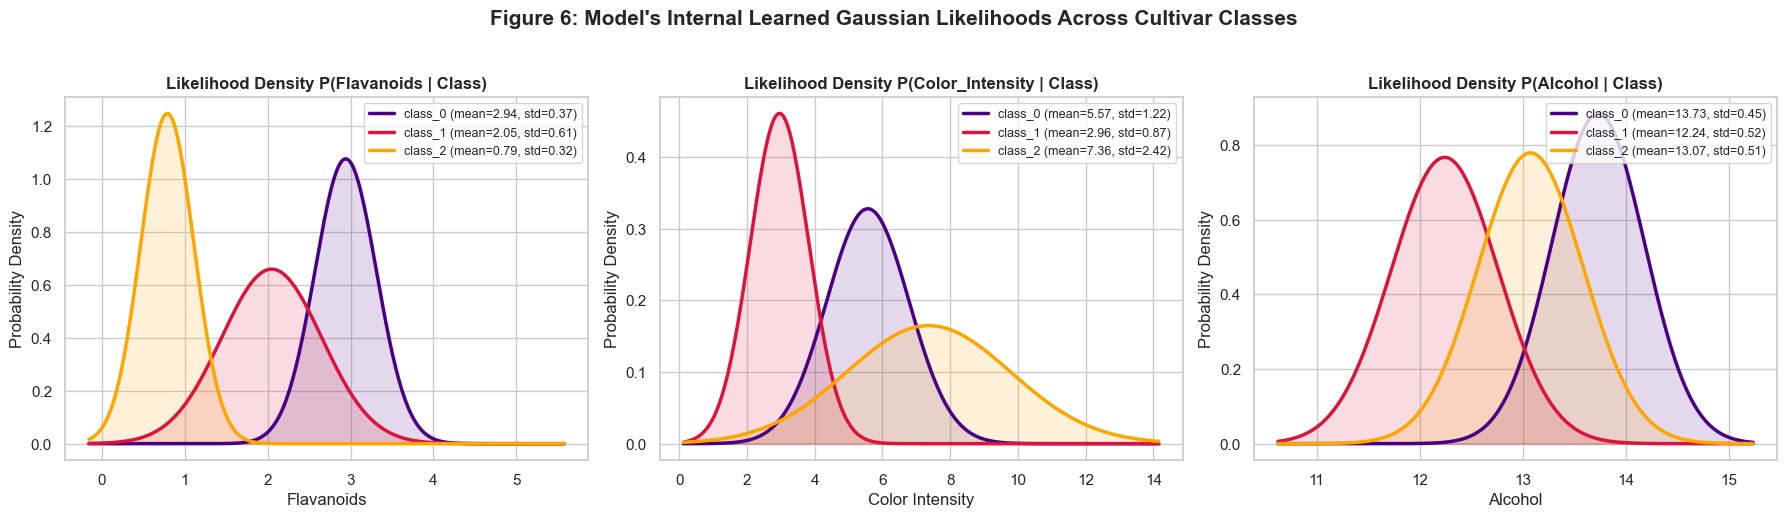

In [13]:
# PLOT 6: The Model's Internal Belief: Gaussian Likelihood Bell Curves P(x | C_k)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

display_features = ['flavanoids', 'color_intensity', 'alcohol']
cultivar_colors = ['indigo', 'crimson', 'orange']

for idx, feat_name in enumerate(display_features):
    feat_idx = list(wine.feature_names).index(feat_name)
    ax = axes[idx]
    
    # Determine span of feature
    x_min = X[:, feat_idx].min() - 0.5 * np.std(X[:, feat_idx])
    x_max = X[:, feat_idx].max() + 0.5 * np.std(X[:, feat_idx])
    x_grid = np.linspace(x_min, x_max, 300)
    
    for c_idx, (c_name, color) in enumerate(zip(wine.target_names, cultivar_colors)):
        mu = gnb.theta_[c_idx, feat_idx]
        sigma = np.sqrt(gnb.var_[c_idx, feat_idx])
        pdf = stats.norm.pdf(x_grid, mu, sigma)
        
        ax.plot(x_grid, pdf, color=color, linewidth=2.5, label=f"{c_name} (mean={mu:.2f}, std={sigma:.2f})")
        ax.fill_between(x_grid, pdf, color=color, alpha=0.15)
        
    ax.set_title(f"Likelihood Density P({feat_name.title()} | Class)", fontweight='bold')
    ax.set_xlabel(feat_name.replace('_', ' ').title())
    ax.set_ylabel("Probability Density")
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle("Figure 6: Model's Internal Learned Gaussian Likelihoods Across Cultivar Classes", y=1.03, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="10-posterior-certainty"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Task 10: Posterior Probability Distributions & Model Certainty</span>


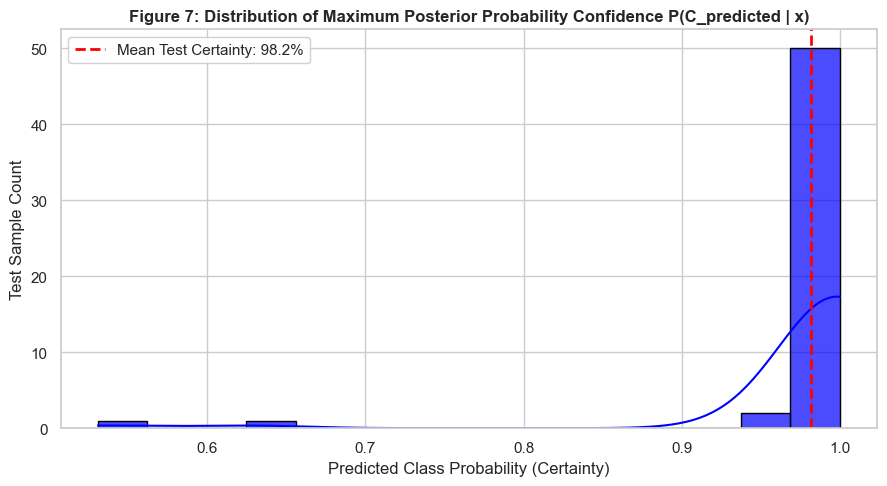

In [14]:
# PLOT 7: Posterior Probability Confidence Distribution
y_test_probs = gnb.predict_proba(X_test)
max_probs = np.max(y_test_probs, axis=1)

plt.figure(figsize=(9, 5))
sns.histplot(max_probs, bins=15, kde=True, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(max_probs), color='red', linestyle='--', linewidth=2,
            label=f'Mean Test Certainty: {np.mean(max_probs)*100:.1f}%')
plt.title("Figure 7: Distribution of Maximum Posterior Probability Confidence P(C_predicted | x)", fontweight='bold')
plt.xlabel("Predicted Class Probability (Certainty)")
plt.ylabel("Test Sample Count")
plt.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

<a id="11-variance-smoothing-tuning"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">11. Task 11: Hyperparameter Optimization -- Variance Smoothing (`var_smoothing`)</span>


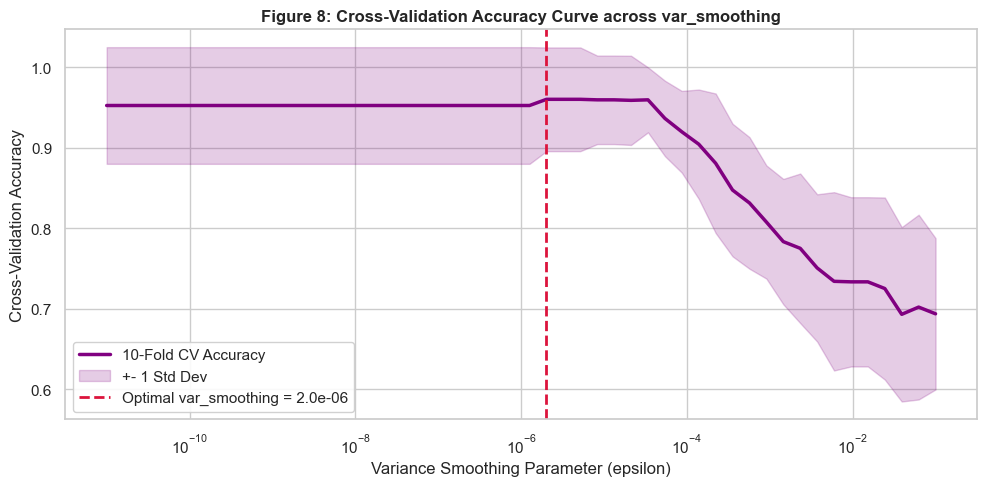

Optimal var_smoothing: 2.02e-06 (Achieves 96.03% CV Accuracy)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",np.float64(2....477251557e-06)


In [15]:
# PLOT 8: Validation Accuracy vs var_smoothing
var_smoothing_grid = np.logspace(-11, -1, 50)
cv_scores = []
cv_stds = []

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for vs in var_smoothing_grid:
    clf = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())
    cv_stds.append(scores.std())

cv_scores = np.array(cv_scores)
cv_stds = np.array(cv_stds)
best_idx = np.argmax(cv_scores)
best_vs = var_smoothing_grid[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(var_smoothing_grid, cv_scores, color='purple', linewidth=2.5, label='10-Fold CV Accuracy')
plt.fill_between(var_smoothing_grid, cv_scores - cv_stds, cv_scores + cv_stds, color='purple', alpha=0.2, label='+- 1 Std Dev')
plt.axvline(best_vs, color='crimson', linestyle='--', linewidth=2, label=f'Optimal var_smoothing = {best_vs:.1e}')
plt.xscale('log')
plt.title("Figure 8: Cross-Validation Accuracy Curve across var_smoothing", fontweight='bold')
plt.xlabel("Variance Smoothing Parameter (epsilon)")
plt.ylabel("Cross-Validation Accuracy")
plt.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"Optimal var_smoothing: {best_vs:.2e} (Achieves {cv_scores[best_idx]*100:.2f}% CV Accuracy)")
best_gnb = GaussianNB(var_smoothing=best_vs)
best_gnb.fit(X_train, y_train)

<a id="12-classifier-benchmarking"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">12. Task 12: Multiclass Classifier Benchmarking (GaussianNB vs ComplementNB vs LogReg vs KNN)</span>


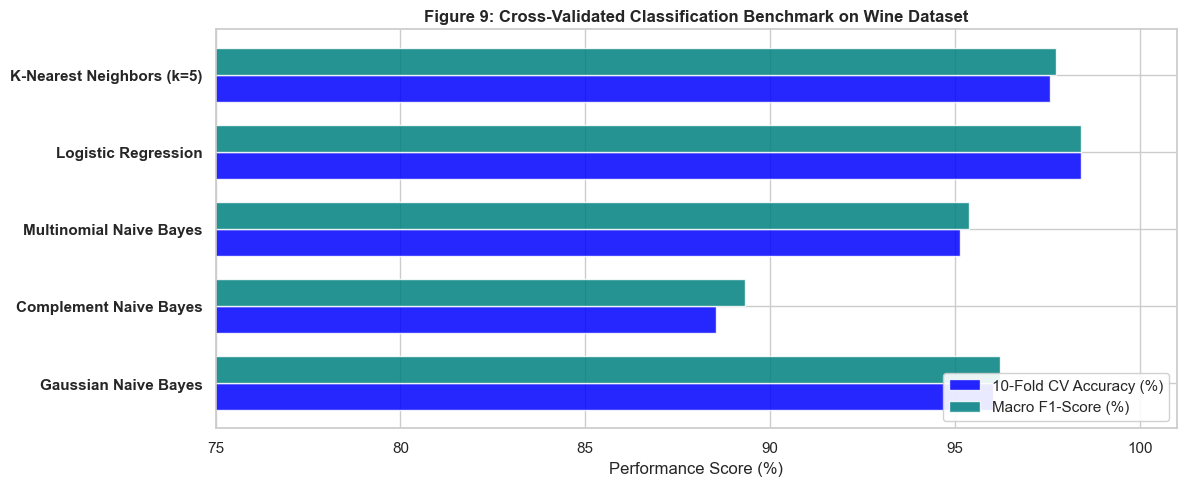

,Algorithm,Mean CV Accuracy,Macro F1-Score
0,Gaussian Naive Bayes,0.960256,0.962076
1,Complement Naive Bayes,0.885256,0.893187
2,Multinomial Naive Bayes,0.951282,0.953699
3,Logistic Regression,0.983974,0.984127
4,K-Nearest Neighbors (k=5),0.975641,0.977393


In [16]:
# PLOT 9: Comparative Cross-Validated Performance Across Classifiers
# For Multinomial/Complement, features must be non-negative, so use MinMaxScaler
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)

models = {
    'Gaussian Naive Bayes': (best_gnb, X_train),
    'Complement Naive Bayes': (ComplementNB(), X_train_minmax),
    'Multinomial Naive Bayes': (MultinomialNB(), X_train_minmax),
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), StandardScaler().fit_transform(X_train)),
    'K-Nearest Neighbors (k=5)': (KNeighborsClassifier(n_neighbors=5), StandardScaler().fit_transform(X_train))
}

bench_results = []
for name, (clf, X_proc) in models.items():
    acc = cross_val_score(clf, X_proc, y_train, cv=cv, scoring='accuracy').mean()
    f1 = cross_val_score(clf, X_proc, y_train, cv=cv, scoring='f1_macro').mean()
    bench_results.append({'Algorithm': name, 'Mean CV Accuracy': acc, 'Macro F1-Score': f1})

df_bench = pd.DataFrame(bench_results)

plt.figure(figsize=(12, 5))
x_ind = np.arange(len(df_bench))
width = 0.35

plt.barh(x_ind - width/2, df_bench['Mean CV Accuracy']*100, width, label='10-Fold CV Accuracy (%)', color='blue', alpha=0.85)
plt.barh(x_ind + width/2, df_bench['Macro F1-Score']*100, width, label='Macro F1-Score (%)', color='teal', alpha=0.85)

plt.yticks(x_ind, df_bench['Algorithm'], fontweight='bold')
plt.xlabel("Performance Score (%)")
plt.title("Figure 9: Cross-Validated Classification Benchmark on Wine Dataset", fontweight='bold')
plt.xlim([75, 101])
plt.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

display(df_bench)

<a id="13-pca-decision-boundary"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">13. Task 13: 2D Decision Boundary Landscapes via PCA Space</span>


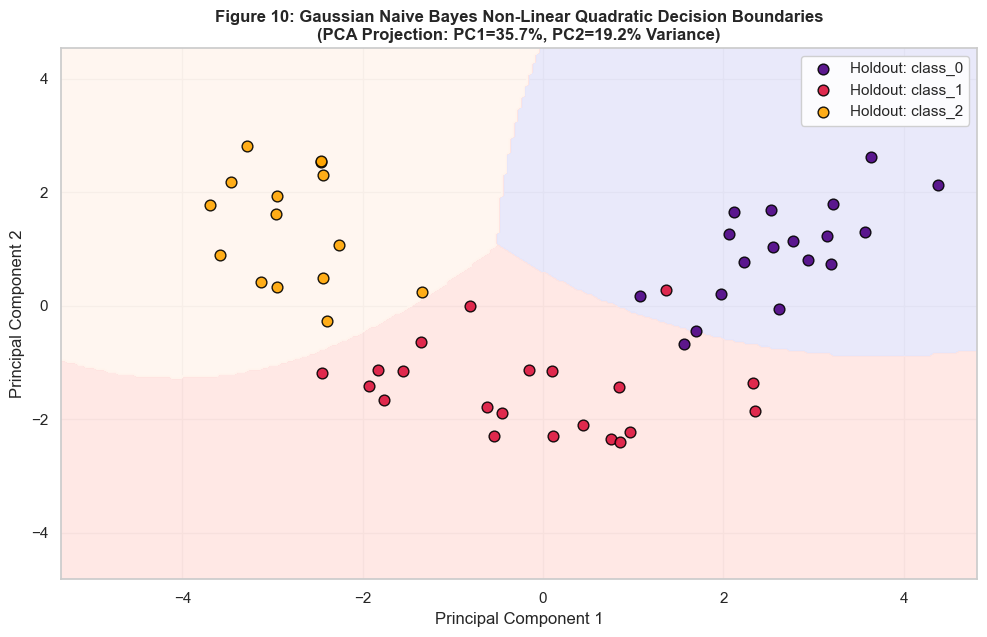

In [17]:
# PLOT 10: 2D Decision Regions via PCA Space
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

clf_pca = GaussianNB()
clf_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.04),
                     np.arange(y_min, y_max, 0.04))

Z = clf_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

from matplotlib.colors import ListedColormap

cmap_light = ListedColormap(['lavender', 'mistyrose', 'seashell'])
cult_colors = ['indigo', 'crimson', 'orange']

plt.figure(figsize=(10, 6.5))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.85)

for class_idx, (c_name, color) in enumerate(zip(wine.target_names, cult_colors)):
    idx = (y_test == class_idx)
    plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], c=color, edgecolor='black',
                s=60, label=f"Holdout: {c_name}", alpha=0.9)

var_exp = pca.explained_variance_ratio_
plt.title(f"Figure 10: Gaussian Naive Bayes Non-Linear Quadratic Decision Boundaries\n(PCA Projection: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}% Variance)", fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(framealpha=0.9, loc='upper right')
plt.tight_layout()
plt.show()

<a id="14-model-evaluation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">14. Task 14: Comprehensive Final Model Evaluation (Confusion Matrix & Multiclass ROC-AUC)</span>


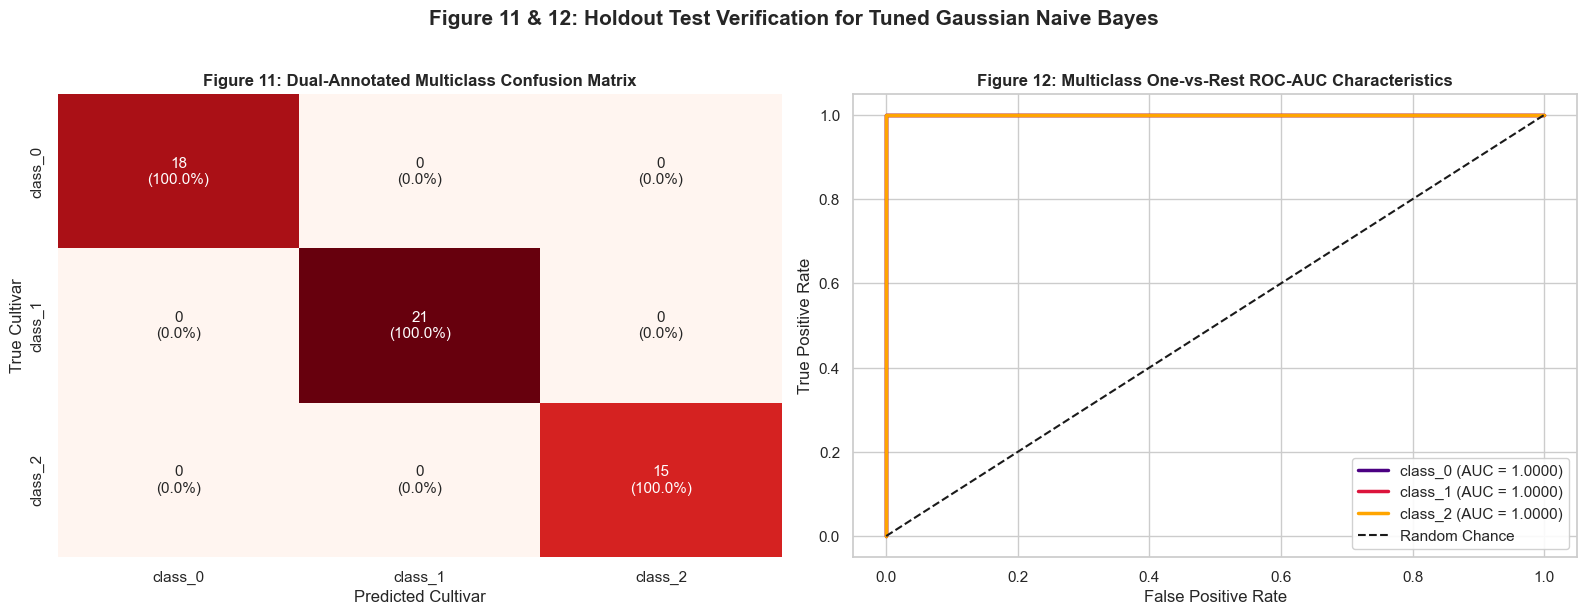

Final Holdout Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [18]:
# PLOT 11 & 12: Dual Confusion Matrix & Multiclass One-vs-Rest ROC Curves
y_test_pred = best_gnb.predict(X_test)
y_test_probs = best_gnb.predict_proba(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Dual Annotated Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_matrix = np.array([[f"{count}\n({norm*100:.1f}%)" for count, norm in zip(row_c, row_n)]
                         for row_c, row_n in zip(cm, cm_norm)])

sns.heatmap(cm, annot=annot_matrix, fmt='', cmap='Reds', ax=ax1, cbar=False,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax1.set_title("Figure 11: Dual-Annotated Multiclass Confusion Matrix", fontweight='bold')
ax1.set_xlabel("Predicted Cultivar")
ax1.set_ylabel("True Cultivar")

# Subplot 2: Multiclass One-vs-Rest ROC Curves
for i, (c_name, color) in enumerate(zip(wine.target_names, cult_colors)):
    y_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_test_probs[:, i])
    roc_score = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{c_name} (AUC = {roc_score:.4f})')

ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance')
ax2.set_title("Figure 12: Multiclass One-vs-Rest ROC-AUC Characteristics", fontweight='bold')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc='lower right', framealpha=0.9)

plt.suptitle("Figure 11 & 12: Holdout Test Verification for Tuned Gaussian Naive Bayes", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print("Final Holdout Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=wine.target_names))

<a id="15-summary-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">15. Task 15: Strengths, Failure Modes & Practical Takeaways</span>


### 🔬 Practical Machine Learning Engineering Takeaways

1. **Why Naive Bayes Works Despite Correlated Features**:
   - Although the conditional independence assumption is virtually always violated in real-world data (e.g. `flavanoids` and `total_phenols` have $r = 0.86$), Naive Bayes often performs remarkably well.
   - For classification, accurate **probability calibration is not required**; only the correct **relative rank order** $\operatorname{argmax}_k P(C_k \mid \mathbf{x})$ matters!

2. **Computational Superiority**:
   - **Training Time**: $O(N \cdot d)$ single pass over the dataset to compute means and standard deviations.
   - **Inference Time**: $O(K \cdot d)$ floating point operations per query.
   - Ideal for real-time inference, high-dimensional streaming environments, and low-compute edge devices.

3. **Variants of Naive Bayes**:
   - **GaussianNB**: Continuous numeric features with bell-shaped distributions.
   - **MultinomialNB**: Discrete word count frequencies in Natural Language Processing (NLP).
   - **BernoulliNB**: Binary indicator features (e.g. word presence/absence).
   - **ComplementNB**: Tailored specifically for severely imbalanced text corpora.
